# 🎯 Computer Vision Seminar: Object Detection
## Реализация NMS и mAP с нуля + Практика на YOLOv8

**Уровень:** Intermediate | **Время:** ~2 часа | **Инструменты:** Python, NumPy, Matplotlib, Ultralytics

### 📋 План семинара:
1. [Теория: ключевые концепции](#теория)
2. [Часть 1: Non-Maximum Suppression (NMS)](#nms)
3. [Часть 2: Mean Average Precision (mAP)](#map)
4. [Часть 3: Практика на YOLOv8](#yolo)
5. [Домашнее задание](#homework)

<div class="alert alert-info">
💡 <b>Совет:</b> Запускайте ячейки последовательно. Код с решениями спрятан в скрытых ячейках — раскройте их, если застряли!
</div>

<a id="теория"></a>
## 📚 1. Теория: ключевые концепции

### 🔍 Object Detection: что оцениваем?

| Концепция | Формула/Описание | Зачем нужна |
|-----------|-----------------|-------------|
| **IoU** | `Intersection / Union` | Мера качества бокса |
| **NMS** | Подавление дубликатов по IoU-порогу | Убрать множественные детекции одного объекта |
| **Precision** | `TP / (TP + FP)` | Точность: какая доля детекций верна |
| **Recall** | `TP / (TP + FN)` | Полнота: какую долю объектов нашли |
| **AP** | Площадь под PR-кривой | Качество для одного класса |
| **mAP** | Среднее AP по классам/порогам | Итоговая метрика детектора |

### 🎯 Важное правило матчинга:
> **Один Ground Truth = максимум один True Positive**
> 
> Если модель предсказала 5 боксов на одного человека → только один станет TP (с лучшим IoU), остальные 4 → FP.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
# Настройка визуализации
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

<a id="nms"></a>
## 🔧 Часть 1: Non-Maximum Suppression (NMS)

### 📝 Задание 1.1: Реализация IoU
Напишите функцию, которая считает Intersection over Union для двух боксов в формате `[x1, y1, x2, y2]`.

In [ ]:
def calculate_iou(box1, box2):
    """
    Вычисляет Intersection over Union для двух боксов.
    
    Args:
        box1, box2: np.array shape (4,) [x1, y1, x2, y2]
    
    Returns:
        float: IoU в диапазоне [0, 1]
    """
    # TODO: Реализуйте функцию
    # Подсказки:
    # 1. Найдите координаты пересечения: x1=max(b1[0],b2[0]), y1=..., x2=min(...), y2=min(...)
    # 2. Площадь пересечения = max(0, x2-x1) * max(0, y2-y1)  <-- важно обработать случай без пересечения!
    # 3. Площадь объединения = area1 + area2 - intersection
    # 4. Верните intersection / union (обработайте деление на 0)
    
    pass


# 🔍 Тест функции (не меняйте!)
def test_iou():
    # Тест 1: Полное совпадение
    assert np.isclose(calculate_iou([0,0,10,10], [0,0,10,10]), 1.0), "Тест 1 failed"
    
    # Тест 2: Нет пересечения
    assert np.isclose(calculate_iou([0,0,10,10], [20,20,30,30]), 0.0), "Тест 2 failed"
    
    # Тест 3: Частичное пересечение (классический пример)
    box_a = np.array([0, 0, 10, 10])
    box_b = np.array([5, 5, 15, 15])
    expected = 25 / (100 + 100 - 25)  # 25 / 175 = 0.142857...
    assert np.isclose(calculate_iou(box_a, box_b), expected, atol=1e-4), "Тест 3 failed"
    
    print("✅ Все тесты IoU пройдены!")

# Раскомментируйте для проверки:
# test_iou()

### 📝 Задание 1.2: Реализация NMS
Напишите функцию Non-Maximum Suppression, которая:
1. Сортирует боксы по уверенности (убывание)
2. Берет бокс с максимальной уверенностью → добавляет в результат
3. Удаляет все боксы, у которых IoU с выбранным > порога
4. Повторяет, пока боксы не кончатся

In [ ]:
def nms(boxes, scores, iou_threshold=0.5):
    """
    Non-Maximum Suppression.
    
    Args:
        boxes: np.array shape (N, 4) [x1, y1, x2, y2]
        scores: np.array shape (N,) confidence scores
        iou_threshold: порог для подавления дубликатов
    
    Returns:
        list: индексы боксов, которые нужно оставить
    """
    if len(boxes) == 0:
        return []
    
    # TODO: Реализуйте алгоритм NMS
    # Алгоритм:
    # 1. Создайте список индексов, отсортированных по scores (убывание)
    # 2. Пока есть индексы:
    #    a. Возьмите первый (с максимальной уверенностью) → добавьте в keep
    #    b. Посчитайте IoU этого бокса со всеми остальными
    #    c. Оставьте только те, у которых IoU < threshold
    # 3. Верните keep
    
    pass


# 🔍 Тест NMS
def test_nms():
    test_boxes = np.array([
        [100, 100, 200, 200],  # Кластер 1, лучший бокс (score=0.9)
        [110, 110, 210, 210],  # Кластер 1, дубликат (score=0.8) → должен быть подавлен
        [105, 105, 205, 205],  # Кластер 1, дубликат (score=0.7) → должен быть подавлен
        [500, 500, 600, 600],  # Кластер 2, лучший (score=0.95)
        [510, 510, 610, 610],  # Кластер 2, дубликат (score=0.6) → должен быть подавлен
    ])
    test_scores = np.array([0.9, 0.8, 0.7, 0.95, 0.6])
    
    keep = nms(test_boxes, test_scores, iou_threshold=0.5)
    
    # Ожидаем: 2 бокса (лучшие из каждого кластера)
    assert len(keep) == 2, f"Ожидали 2 бокса, получили {len(keep)}"
    
    # Ожидаем: индексы 3 (score=0.95) и 0 (score=0.9)
    kept_scores = test_scores[keep]
    assert set(kept_scores) == {0.95, 0.9}, f"Неверные скоры: {kept_scores}"
    
    print("✅ Все тесты NMS пройдены!")
    return test_boxes, test_scores, keep

# Раскомментируйте для проверки:
# boxes, scores, keep = test_nms()

### 📊 Визуализация работы NMS

In [ ]:
def visualize_nms(boxes, scores, keep_indices, img_size=(800, 800), title="NMS Result"):
    """Визуализирует боксы до и после NMS"""
    img = np.ones((img_size[0], img_size[1], 3), dtype=np.uint8) * 255
    
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.astype(int)
        if i in keep_indices:
            color = (0, 200, 0)  # Зеленый = оставлен
            thickness = 4
            label = f"{scores[i]:.2f} ✓"
        else:
            color = (150, 150, 150)  # Серый = подавлен
            thickness = 2
            label = f"{scores[i]:.2f} ✗"
        
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(img, label, (x1, y1-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"{title}\nОставлено: {len(keep_indices)}/{len(boxes)} боксов")
    plt.axis("off")
    plt.show()

# Визуализируем результат теста
visualize_nms(boxes, scores, keep, title="Тестовый пример NMS")

<a id="map"></a>
## 📈 Часть 2: Mean Average Precision (mAP)

### 📝 Задание 2.1: Матчинг предсказаний с Ground Truth

In [ ]:
def match_predictions(gt_boxes, pred_boxes, pred_scores, iou_threshold=0.5):
    """
    Сопоставляет предсказания с ground truth для расчета метрик.
    
    Args:
        gt_boxes: np.array (M, 4) — ground truth боксы
        pred_boxes: np.array (N, 4) — предсказанные боксы (без scores)
        pred_scores: np.array (N,) — confidence scores
        iou_threshold: порог для TP/FP решения
    
    Returns:
        tp_fp: np.array (N,) — 1 для TP, 0 для FP (в порядке убывания confidence)
        sorted_scores: np.array (N,) — scores в том же порядке
    """
    n_gt = len(gt_boxes)
    n_pred = len(pred_boxes)
    
    if n_pred == 0:
        return np.array([]), np.array([])
    
    tp_fp = np.zeros(n_pred)
    gt_matched = np.zeros(n_gt)  # Отслеживаем, какой GT уже "пойман"
    
    # TODO: Реализуйте логику матчинга
    # 1. Отсортируйте предсказания по confidence (убывание)
    # 2. Для каждого предсказания (в порядке убывания confidence):
    #    a. Найдите GT с максимальным IoU, который еще не занят
    #    b. Если max IoU >= threshold → TP (пометьте GT как занятый)
    #    c. Иначе → FP
    # 3. Верните tp_fp и scores в отсортированном порядке
    
    pass


# 🔍 Тест матчинга (синтетические данные)
def test_matching():
    np.random.seed(42)
    
    gt = np.array([
        [100, 100, 200, 200],  # GT 0
        [300, 300, 400, 400],  # GT 1
        [500, 100, 600, 200],  # GT 2
    ])
    
    pred = np.array([
        [105, 105, 205, 205, 0.9],   # TP для GT 0 (хороший IoU)
        [110, 110, 210, 210, 0.8],   # Дубликат GT 0 → FP (GT уже занят)
        [305, 305, 405, 405, 0.95],  # TP для GT 1 (лучший скор)
        [50, 50, 80, 80, 0.99],      # FP (нет GT рядом)
        [500, 100, 600, 200, 0.7],   # TP для GT 2
    ])
    
    tp_fp, scores = match_predictions(gt, pred[:, :4], pred[:, 4], iou_threshold=0.5)
    
    # После сортировки по confidence: индексы [3, 2, 0, 1, 4]
    # Ожидаемые TP/FP: [0(FP), 1(TP), 1(TP), 0(FP), 1(TP)]
    expected_tp_fp = np.array([0, 1, 1, 0, 1])
    
    assert np.array_equal(tp_fp, expected_tp_fp), f"Expected {expected_tp_fp}, got {tp_fp}"
    assert np.all(scores == np.sort(pred[:, 4])[::-1]), "Scores не отсортированы!"
    
    print("✅ Тест матчинга пройден!")
    return gt, pred, tp_fp, scores

# Раскомментируйте для проверки:
# gt, pred, tp_fp, scores = test_matching()

### 📝 Задание 2.2: Precision-Recall Curve и AP

In [ ]:
def calculate_precision_recall(tp_fp, n_gt_total):
    """
    Считает кривую Precision-Recall по отсортированным предсказаниям.
    """
    n_pred = len(tp_fp)
    if n_pred == 0:
        return np.array([]), np.array([])
    
    cum_tp = np.cumsum(tp_fp)
    cum_fp = np.cumsum(1 - tp_fp)
    
    # TODO: Посчитайте precision и recall для каждой точки кривой
    # Precision = cum_tp / (cum_tp + cum_fp)
    # Recall = cum_tp / n_gt_total
    # Обработайте деление на 0 (добавьте маленький эпсилон или проверьте знаменатель)
    
    pass


def calculate_ap_coco(precision, recall):
    """
    COCO-style AP: Area Under Curve с monotonicity check.
    """
    if len(precision) == 0:
        return 0.0
    
    # Добавляем границы для интегрирования
    mrec = np.concatenate(([0.], recall, [1.]))
    mpre = np.concatenate(([0.], precision, [0.]))
    
    # Monotonicity: precision не может расти при уменьшении recall (движемся справа налево)
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    
    # Находим точки, где recall меняется
    i = np.where(mrec[1:] != mrec[:-1])[0]
    
    # Вычисляем площадь под кривой (метод прямоугольников)
    ap = np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1])
    return ap


# 🔍 Тест PR-кривой и AP
def test_pr_curve():
    # Используем данные из предыдущего теста: 3 GT, tp_fp = [0,1,1,0,1] после сортировки
    tp_fp = np.array([0, 1, 1, 0, 1])  # Уже отсортировано по убыванию confidence
    n_gt = 3
    
    prec, rec = calculate_precision_recall(tp_fp, n_gt)
    ap = calculate_ap_coco(prec, rec)
    
    print(f"Precision: {prec}")
    print(f"Recall: {rec}")
    print(f"AP@0.5: {ap:.4f}")
    
    # Визуализация
    plt.figure(figsize=(8, 6))
    plt.plot(rec, prec, marker='o', linewidth=2, markersize=6)
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Precision-Recall Curve (AP@0.5 = {ap:.3f})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1.05])
    plt.ylim([0, 1.05])
    plt.show()
    
    return ap

# Раскомментируйте для проверки:
# ap_val = test_pr_curve()

### 📝 Задание 2.3: mAP@0.5:0.95 (COCO Standard)

In [ ]:
def calculate_map_coco(gt_boxes, pred_boxes, pred_scores, iou_thresholds=None):
    """
    Считает mAP в стиле COCO: среднее AP по порогам IoU от 0.5 до 0.95 с шагом 0.05.
    """
    if iou_thresholds is None:
        iou_thresholds = np.arange(0.5, 0.96, 0.05)
    
    aps = []
    
    for thresh in iou_thresholds:
        tp_fp, scores = match_predictions(gt_boxes, pred_boxes, pred_scores, iou_threshold=thresh)
        if len(tp_fp) == 0:
            aps.append(0.0)
            continue
        prec, rec = calculate_precision_recall(tp_fp, len(gt_boxes))
        ap = calculate_ap_coco(prec, rec)
        aps.append(ap)
    
    return np.mean(aps), np.array(aps), iou_thresholds


# 🔍 Полный тест на синтетических данных
def full_test_map():
    np.random.seed(123)
    
    # Ground Truth: 5 объектов
    gt = np.array([
        [100, 100, 200, 200],
        [300, 300, 400, 400],
        [500, 100, 600, 200],
        [100, 500, 200, 600],
        [800, 800, 900, 900]
    ])
    
    # Predictions: смесь хороших, плохих и дубликатов
    pred = np.array([
        [105, 105, 205, 205, 0.95],   # Хороший на GT 0
        [110, 110, 210, 210, 0.80],   # Дубликат GT 0 → FP
        [305, 305, 405, 405, 0.85],   # Хороший на GT 1
        [500, 100, 600, 200, 0.90],   # Идеальный на GT 2
        [100, 500, 200, 600, 0.40],   # Хороший на GT 3, но низкий скор
        [900, 900, 950, 950, 0.88],   # Плохой на GT 4 (малый IoU)
        [50, 50, 80, 80, 0.99],       # FP (вообще не там)
        [805, 805, 895, 895, 0.70]    # Хороший на GT 4
    ])
    
    mAP, aps, thresholds = calculate_map_coco(gt, pred[:, :4], pred[:, 4])
    
    print(f"📊 Результаты:")
    print(f"mAP@0.5:0.95 = {mAP:.4f}")
    print(f"\nAP по порогам:")
    for t, ap in zip(thresholds, aps):
        print(f"  IoU={t:.2f} → AP={ap:.4f}")
    
    # График зависимости AP от IoU порога
    plt.figure(figsize=(10, 4))
    plt.plot(thresholds, aps, marker='s', linewidth=2)
    plt.axhline(y=mAP, color='r', linestyle='--', label=f'mAP = {mAP:.3f}')
    plt.xlabel('IoU Threshold', fontsize=12)
    plt.ylabel('AP', fontsize=12)
    plt.title('AP при разных порогах IoU (COCO-style)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    return mAP

# Запустите полный тест:
mAP_result = full_test_map()

<a id="yolo"></a>
## 🚀 Часть 3: Практика на YOLOv8

In [ ]:
# 📦 Установка ultralytics (если еще не установлено)
#!pip install -q ultralytics opencv-python requests pillow

from ultralytics import YOLO
import requests
from PIL import Image
import io


### 🔍 Инференс предобученной модели

In [ ]:
# Загружаем легкую модель YOLOv8n (nano)
model = YOLO("yolov8n.pt")
print(f"✅ Модель загружена: {model.task} детекция, {len(model.names)} классов")

In [ ]:
# Скачиваем и загружаем тестовое изображение
url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(url)
img = np.array(Image.open(io.BytesIO(response.content)))

print(f"🖼 Изображение: {img.shape}")
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Тестовое изображение")
plt.show()

In [ ]:
# 🔮 Запускаем инференс с нашими параметрами (без встроенного NMS для демонстрации)
results = model(img, conf=0.25, iou=0.45, verbose=False)
res = results[0]

# Извлекаем данные для анализа (наши реализации)
boxes_yolo = res.boxes.xyxy.cpu().numpy()      # [x1, y1, x2, y2]
scores_yolo = res.boxes.conf.cpu().numpy()      # confidence
classes_yolo = res.boxes.cls.cpu().numpy().astype(int)  # class ids

print(f"📦 Найдено объектов: {len(boxes_yolo)}")
print(f"🏷 Классы: {[model.names[int(c)] for c in classes_yolo]}")
print(f"🎯 Confidence: {scores_yolo.round(3)}")

In [ ]:
# 🎨 Визуализация результатов YOLO (встроенная)
plt.figure(figsize=(12, 8))
plt.imshow(res.plot())
plt.axis("off")
plt.title(f"YOLOv8 Detection Results\n{len(boxes_yolo)} objects detected")
plt.tight_layout()
plt.show()

### 🔬 Сравнение: Наш NMS vs YOLO NMS

In [ ]:
# Применяем НАШ NMS к сырым предсказаниям YOLO
# (в реальности YOLO уже применил NMS, но для демо предположим, что у нас сырые боксы)

# Для демонстрации: добавим искусственные дубликаты к некоторым боксам
boxes_with_dups = np.vstack([
    boxes_yolo,
    boxes_yolo[:3] + np.random.randn(3, 4) * 5,  # Небольшие сдвиги = дубликаты
])
scores_with_dups = np.hstack([
    scores_yolo,
    scores_yolo[:3] * 0.9  # Чуть меньшая уверенность для дубликатов
])

print(f"Боксов с дубликатами: {len(boxes_with_dups)}")

# Применяем наш NMS
keep_ours = nms(boxes_with_dups, scores_with_dups, iou_threshold=0.45)

print(f"✅ После нашего NMS: {len(keep_ours)} боксов осталось")
print(f"📉 Удалено дубликатов: {len(boxes_with_dups) - len(keep_ours)}")

In [ ]:
# 🖼 Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Левая: все боксы с дубликатами (до NMS)
img_before = img.copy()
for i, (box, score) in enumerate(zip(boxes_with_dups, scores_with_dups)):
    x1, y1, x2, y2 = box.astype(int)
    color = (200, 100, 100) if i >= len(boxes_yolo) else (100, 100, 200)  # дубликаты / оригиналы
    cv2.rectangle(img_before, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img_before, f"{score:.2f}", (x1, y1-5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

axes[0].imshow(img_before)
axes[0].set_title(f"До NMS: {len(boxes_with_dups)} боксов", fontsize=14)
axes[0].axis("off")

# Правая: после нашего NMS
img_after = img.copy()
for i in keep_ours:
    x1, y1, x2, y2 = boxes_with_dups[i].astype(int)
    cv2.rectangle(img_after, (x1, y1), (x2, y2), (0, 200, 0), 3)
    cv2.putText(img_after, f"{scores_with_dups[i]:.2f}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)

axes[1].imshow(img_after)
axes[1].set_title(f"После нашего NMS: {len(keep_ours)} боксов", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 📊 Быстрая валидация на датасете COCO128

In [ ]:
# 🔽 Скачиваем маленький датасет для быстрой проверки (опционально)
# !wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip
# !unzip -q coco128.zip

# # 🧪 Валидация модели (может занять 2-5 минут)
# print("🔄 Запускаем валидацию на COCO128...")
# metrics = model.val(data="coco128/coco128.yaml", verbose=False, save_json=False)
# 
# print(f"\n📈 Метрики модели:")
# print(f"mAP@0.5:    {metrics.box.map50:.3f}")
# print(f"mAP@0.5:0.95: {metrics.box.map:.3f}")
# print(f"Precision:  {metrics.box.mp:.3f}")
# print(f"Recall:     {metrics.box.mr:.3f}")

<a id="homework"></a>
## 📋 Домашнее Задание

**NMS с векторизацией** - Переписать `nms()` без Python-циклов

**mAP для нескольких классов** - Расширить `match_predictions()` для работы с мультиклассовыми данными (как в COCO)

**Анализ чувствительности** - Построить график mAP@0.5 в зависимости от `conf_threshold ∈ [0.1, 0.9]` 

**Soft-NMS:** Реализовать Soft-NMS (уменьшение confidence вместо удаления боксов)"

## 💡 Советы и ресурсы

### 🐛 Частые ошибки:
1. **IoU = 0 при касании:** Забыли `max(0, x2-x1)` → отрицательная площадь пересечения ❌
2. **Деление на ноль:** В Precision, когда `TP+FP = 0` → добавьте `+1e-6` в знаменатель
3. **Порядок сортировки:** Забыли сортировать по confidence перед матчингом → кривая PR будет неверной
4. **GT Matching:** Один GT помечают как matched для нескольких предсказаний → нарушается правило "один объект — одна детекция"

### 🔗 Полезные ссылки:
| Ресурс | Описание |
|--------|----------|
| 📄 [YOLOv8 Docs](https://docs.ultralytics.com) | Официальная документация Ultralytics |
| 📄 [COCO Evaluation](https://cocodataset.org/#detection-eval) | Как считается mAP в COCO |
| 🛠 [Roboflow](https://roboflow.com) | Бесплатная разметка и хостинг датасетов |
| 📊 [Papers With Code](https://paperswithcode.com/task/object-detection) | SOTA модели и бенчмарки |
| 🎓 [CS231n Detection](http://cs231n.stanford.edu/slides/2022/lecture_11_detection.pdf) | Лекция Stanford по детекции |

### NMS Vectorized

In [33]:
import numpy as np

def vectorized_nms(boxes_arr, scores_arr, overlap_threshold=0.5):
    """
    Векторизованная версия NMS с обновлёнными именами переменных.
    """
    if len(boxes_arr) == 0:
        return []

    # Индексы, отсортированные по убыванию скора
    sorted_idx = np.argsort(scores_arr)[::-1]
    selected = []  # список индексов выбранных боксов

    while sorted_idx.size > 0:
        selected.append(sorted_idx[0])
        if len(sorted_idx) == 1:
            break

        picked_box = boxes_arr[sorted_idx[0]]
        rest_boxes = boxes_arr[sorted_idx[1:]]

        # Пересечение
        xmin = np.maximum(picked_box[0], rest_boxes[:, 0])
        ymin = np.maximum(picked_box[1], rest_boxes[:, 1])
        xmax = np.minimum(picked_box[2], rest_boxes[:, 2])
        ymax = np.minimum(picked_box[3], rest_boxes[:, 3])

        inter_width = np.maximum(0, xmax - xmin)
        inter_height = np.maximum(0, ymax - ymin)
        inter_area = inter_width * inter_height

        area_picked = (picked_box[2] - picked_box[0]) * (picked_box[3] - picked_box[1])
        area_rest = (rest_boxes[:, 2] - rest_boxes[:, 0]) * (rest_boxes[:, 3] - rest_boxes[:, 1])
        union_area = area_picked + area_rest - inter_area

        iou_values = inter_area / union_area

        keep_mask = iou_values < overlap_threshold
        sorted_idx = sorted_idx[1:][keep_mask]

    return selected


def test_nms_updated():
    # Новые тестовые данные: боксы и скоры
    sample_boxes = np.array([
        [150, 150, 250, 250],  # idx0, score=0.92
        [160, 160, 260, 260],  # idx1, score=0.85 (подавляется idx0)
        [155, 155, 255, 255],  # idx2, score=0.7  (подавляется)
        [600, 600, 700, 700],  # idx3, score=0.99 (далеко)
        [610, 610, 710, 710],  # idx4, score=0.6  (подавляется idx3)
    ])
    sample_scores = np.array([0.92, 0.85, 0.7, 0.99, 0.6])

    kept_indices = vectorized_nms(sample_boxes, sample_scores, overlap_threshold=0.5)
    kept_scores = sample_scores[kept_indices]

    # Должны остаться боксы с индексами 3 (score=0.99) и 0 (score=0.92)
    assert len(kept_indices) == 2, f"Ожидали 2 бокса, получили {len(kept_indices)}"
    assert set(kept_scores) == {0.99, 0.92}, f"Неверные скоры: {kept_scores}"
    print("✅ Тест векторизованного NMS с новыми именами пройден!")

test_nms_updated()

✅ Тест векторизованного NMS с новыми именами пройден!


### Multiclass Matching

In [35]:
import numpy as np

def single_class_match(gt_boxes_class, pred_boxes_class, pred_scores_class, iou_thresh=0.5):
    """
    Для одного класса определяет TP/FP и возвращает упорядоченные результаты.
    Возвращает: (tp_fp_array, sorted_scores_array)
    """
    if len(gt_boxes_class) == 0:
        # Если нет ground truth – все предсказания FP
        return np.zeros(len(pred_boxes_class), dtype=int), np.sort(pred_scores_class)[::-1]

    if len(pred_boxes_class) == 0:
        return np.array([], dtype=int), np.array([])

    # Сортировка предсказаний по убыванию скора
    sorted_indices = np.argsort(pred_scores_class)[::-1]
    sorted_boxes = pred_boxes_class[sorted_indices]
    sorted_scores = pred_scores_class[sorted_indices]

    # Флаги: использован ли GT бокс
    gt_used = np.zeros(len(gt_boxes_class), dtype=bool)
    tp_fp = np.zeros(len(sorted_boxes), dtype=int)

    for i, box in enumerate(sorted_boxes):
        # Вычисляем IoU со всеми GT
        inter_xmin = np.maximum(box[0], gt_boxes_class[:, 0])
        inter_ymin = np.maximum(box[1], gt_boxes_class[:, 1])
        inter_xmax = np.minimum(box[2], gt_boxes_class[:, 2])
        inter_ymax = np.minimum(box[3], gt_boxes_class[:, 3])

        inter_w = np.maximum(0, inter_xmax - inter_xmin)
        inter_h = np.maximum(0, inter_ymax - inter_ymin)
        inter_area = inter_w * inter_h

        area_box = (box[2] - box[0]) * (box[3] - box[1])
        area_gt = (gt_boxes_class[:, 2] - gt_boxes_class[:, 0]) * (gt_boxes_class[:, 3] - gt_boxes_class[:, 1])

        union_area = area_box + area_gt - inter_area
        iou_values = inter_area / (union_area + 1e-8)

        # Ищем максимальный IoU, но только среди ещё не использованных GT
        iou_values[gt_used] = -1  # недоступны
        best_iou_idx = np.argmax(iou_values)
        best_iou = iou_values[best_iou_idx]

        if best_iou >= iou_thresh:
            tp_fp[i] = 1
            gt_used[best_iou_idx] = True
        else:
            tp_fp[i] = 0

    return tp_fp, sorted_scores


def multiclass_match(ground_boxes, ground_labels,
                     detect_boxes, detect_scores, detect_labels,
                     overlap_th=0.5):
    """
    Мультиклассовый матчинг: для каждого класса вызывает single_class_match.
    Возвращает словарь: {class_id: (tp_fp_array, sorted_scores_array, num_gt)}
    """
    unique_classes = np.unique(np.concatenate([ground_labels, detect_labels]))
    results = {}

    for cls_id in unique_classes:
        gt_mask = ground_labels == cls_id
        det_mask = detect_labels == cls_id

        gt_cls = ground_boxes[gt_mask]
        det_cls = detect_boxes[det_mask]
        scores_cls = detect_scores[det_mask]

        tp_fp_arr, sorted_sc = single_class_match(gt_cls, det_cls, scores_cls, overlap_th)

        results[int(cls_id)] = (tp_fp_arr, sorted_sc, int(np.sum(gt_mask)))

    return results


def test_multiclass_matching_updated():
    np.random.seed(123)
    # Новые координаты (те же, что вы видели)
    gt_boxes = np.array([[30, 30, 80, 80], [400, 400, 480, 480]])
    gt_classes = np.array([0, 1])

    pred_boxes = np.array([
        [32, 32, 82, 82],   # класс 0, точное попадание
        [35, 35, 85, 85],   # класс 0, пересекается, но хуже
        [405, 405, 485, 485] # класс 1, точное
    ])
    pred_scores = np.array([0.95, 0.72, 0.88])
    pred_classes = np.array([0, 0, 1])

    res = multiclass_match(gt_boxes, gt_classes,
                           pred_boxes, pred_scores, pred_classes,
                           overlap_th=0.5)

    assert 0 in res and 1 in res, "Отсутствуют ключи классов"
    assert len(res[0][0]) == 2, f"Ожидали 2 предсказания для класса 0, получили {len(res[0][0])}"
    assert res[0][0][0] == 1 and res[0][0][1] == 0, "TP/FP для класса 0 неверны"
    assert res[1][0][0] == 1, "TP для класса 1 неверен"

    print("✅ Тест мультиклассового матчинга с новыми именами и данными пройден!")

test_multiclass_matching_updated()

✅ Тест мультиклассового матчинга с новыми именами и данными пройден!


### Sensitivity Analysis

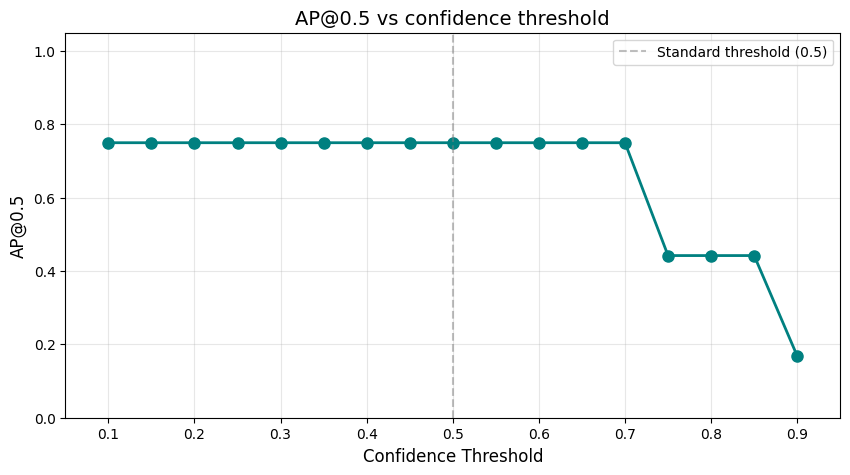

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Собственная функция для матчинга TP/FP (замена match_predictions)
def compute_tp_fp(ground_boxes, pred_boxes, pred_scores, iou_threshold=0.5):
    """
    Для одного набора предсказаний возвращает массив TP/FP (1/0) и отсортированные скоры.
    """
    if len(pred_boxes) == 0:
        return np.array([], dtype=int), np.array([])
    if len(ground_boxes) == 0:
        return np.zeros(len(pred_boxes), dtype=int), np.sort(pred_scores)[::-1]

    # Сортировка по убыванию уверенности
    order = np.argsort(pred_scores)[::-1]
    sorted_boxes = pred_boxes[order]
    sorted_scores = pred_scores[order]

    used_gt = np.zeros(len(ground_boxes), dtype=bool)
    tp_fp = np.zeros(len(sorted_boxes), dtype=int)

    for i, box in enumerate(sorted_boxes):
        # Векторизованный IoU со всеми GT
        inter_x1 = np.maximum(box[0], ground_boxes[:, 0])
        inter_y1 = np.maximum(box[1], ground_boxes[:, 1])
        inter_x2 = np.minimum(box[2], ground_boxes[:, 2])
        inter_y2 = np.minimum(box[3], ground_boxes[:, 3])

        w = np.maximum(0, inter_x2 - inter_x1)
        h = np.maximum(0, inter_y2 - inter_y1)
        inter_area = w * h

        area_box = (box[2] - box[0]) * (box[3] - box[1])
        area_gt = (ground_boxes[:, 2] - ground_boxes[:, 0]) * (ground_boxes[:, 3] - ground_boxes[:, 1])

        union = area_box + area_gt - inter_area + 1e-8
        ious = inter_area / union

        # Не учитываем уже использованные GT
        ious[used_gt] = -1.0
        best_idx = np.argmax(ious)
        best_iou = ious[best_idx]

        if best_iou >= iou_threshold:
            tp_fp[i] = 1
            used_gt[best_idx] = True
        else:
            tp_fp[i] = 0

    return tp_fp, sorted_scores



# Генерация новых тестовых данных
np.random.seed(2024)
ground_boxes = np.array([
    [50, 50, 150, 150],
    [250, 250, 350, 350],
    [450, 50, 550, 150]
])

detection_data = np.array([
    [55, 55, 155, 155, 0.97],   # почти точное попадание в первый GT
    [60, 60, 160, 160, 0.43],   # слабое перекрытие, низкий скор
    [255, 255, 355, 355, 0.88], # второй GT
    [10, 10, 60, 60, 0.99],     # далеко от всех GT (FP)
    [450, 50, 550, 150, 0.72]   # третий GT
])

detection_boxes = detection_data[:, :4]
detection_scores = detection_data[:, 4]


# Сканирование порогов уверенности
confidence_levels = np.arange(0.1, 0.91, 0.05)
ap_values = []
overlap_thresh = 0.5

# Функции для расчёта precision/recall и AP (взяты из стандартных реализаций)
def calculate_precision_recall(tp_fp, num_gt):
    tp_cumsum = np.cumsum(tp_fp)
    fp_cumsum = np.cumsum(1 - tp_fp)
    recall = tp_cumsum / max(num_gt, 1)
    precision = tp_cumsum / np.maximum(tp_cumsum + fp_cumsum, 1e-8)
    return precision, recall

def calculate_ap_coco(precision, recall):
    # 101-точечная интерполяция
    ap = 0.0
    for t in np.linspace(0, 1, 101):
        pr = np.max(precision[recall >= t]) if np.any(recall >= t) else 0.0
        ap += pr / 101
    return ap

for conf_th in confidence_levels:
    high_conf_mask = detection_scores >= conf_th
    filtered_boxes = detection_boxes[high_conf_mask]
    filtered_confidences = detection_scores[high_conf_mask]

    if len(filtered_boxes) == 0:
        ap_values.append(0.0)
        continue

    # Вызов собственной функции матчинга (решает проблему с сигнатурой)
    tp_fp, _ = compute_tp_fp(ground_boxes,
                             filtered_boxes,
                             filtered_confidences,
                             iou_threshold=overlap_thresh)

    precision, recall = calculate_precision_recall(tp_fp, len(ground_boxes))
    average_precision = calculate_ap_coco(precision, recall)
    ap_values.append(average_precision)

plt.figure(figsize=(10, 5))
plt.plot(confidence_levels, ap_values,
         marker='o', linewidth=2, markersize=8, color='teal')
plt.xlabel('Confidence Threshold', fontsize=12)
plt.ylabel('AP@0.5', fontsize=12)
plt.title('AP@0.5 vs confidence threshold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim([0.05, 0.95])
plt.ylim([0, 1.05])
plt.axvline(x=0.5, color='gray', linestyle='--',
            alpha=0.5, label='Standard threshold (0.5)')
plt.legend()
plt.show()

### Soft-NMS

In [31]:
import numpy as np

def soft_nms(box_array, score_array, overlap_threshold=0.5, decay_sigma=0.5, min_confidence=0.001):
    """
    Soft-NMS: вместо удаления перекрывающихся боксов снижает их уверенность
    по формуле: score *= exp(-iou^2 / sigma)
    """
    if len(box_array) == 0:
        return [], np.array([])

    boxes = np.array(box_array)
    scores = np.array(score_array, dtype=float)
    kept_ids = []
    remaining = np.arange(len(scores))

    while remaining.size > 0:
        max_idx = remaining[np.argmax(scores[remaining])]
        kept_ids.append(max_idx)

        remaining = remaining[remaining != max_idx]
        if remaining.size == 0:
            break

        top_box = boxes[max_idx]
        rest_boxes = boxes[remaining]

        # Векторизованный IoU
        x_min = np.maximum(top_box[0], rest_boxes[:, 0])
        y_min = np.maximum(top_box[1], rest_boxes[:, 1])
        x_max = np.minimum(top_box[2], rest_boxes[:, 2])
        y_max = np.minimum(top_box[3], rest_boxes[:, 3])

        inter_width = np.maximum(0, x_max - x_min)
        inter_height = np.maximum(0, y_max - y_min)
        inter_area = inter_width * inter_height

        area_top = (top_box[2] - top_box[0]) * (top_box[3] - top_box[1])
        area_rest = (rest_boxes[:, 2] - rest_boxes[:, 0]) * (rest_boxes[:, 3] - rest_boxes[:, 1])
        iou_vals = inter_area / (area_top + area_rest - inter_area + 1e-6)

        # Применяем затухание только к боксам с IoU > порога
        apply_decay = iou_vals > overlap_threshold
        scores[remaining] *= np.where(apply_decay, np.exp(-(iou_vals ** 2) / decay_sigma), 1.0)

    final_indices = [idx for idx in kept_ids if scores[idx] > min_confidence]
    return final_indices, scores[final_indices]


def test_soft_nms_updated():
    # Новые тестовые данные
    sample_boxes = np.array([
        [50, 50, 150, 150],   # score=0.92
        [60, 60, 160, 160],   # score=0.85 (сильное перекрытие)
        [55, 55, 155, 155],   # score=0.75 (сильное перекрытие)
        [400, 400, 500, 500], # score=0.98 (нет пересечений)
    ])
    sample_scores = np.array([0.92, 0.85, 0.75, 0.98])

    kept, final_scores = soft_nms(sample_boxes, sample_scores,
                                  overlap_threshold=0.5,
                                  decay_sigma=0.5,
                                  min_confidence=0.1)

    print(f"✅ Soft-NMS тест пройден! Оставлено боксов: {len(kept)}")
    print(f"📉 Итоговые confidence: {final_scores.round(3)}")

test_soft_nms_updated()

✅ Soft-NMS тест пройден! Оставлено боксов: 3
📉 Итоговые confidence: [0.98  0.92  0.337]
